# ARIMA and SARIMA

## Overview

ARIMA (AutoRegressive Integrated Moving Average) models a stationary time series as a combination of:
- **AR(p):** regression on p lagged values
- **I(d):** d rounds of differencing to achieve stationarity
- **MA(q):** regression on q lagged forecast errors

**SARIMA** extends this with seasonal counterparts (P, D, Q, s):
`SARIMA(p,d,q)(P,D,Q,s)` where s is the seasonal period (12 for monthly).

**Order selection:**
1. Check stationarity (ADF/KPSS) → determine d
2. Check seasonal ACF → determine D
3. Read ACF (MA order q) and PACF (AR order p) on differenced series
4. Fit candidates and compare AIC/BIC
5. Check residuals: white noise, no autocorrelation

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

rng = np.random.default_rng(42)
dates = pd.date_range("2012-01-01", periods=144, freq="MS")
trend    = np.linspace(2.5, 4.2, 144)
seasonal = 0.8*np.sin(2*np.pi*np.arange(144)/12)
noise    = rng.normal(0, 0.25, 144)
ts = pd.Series(trend+seasonal+noise, index=dates, name="nitrate")
train, test = ts.iloc[:120], ts.iloc[120:]
print(f"Train: {len(train)}, Test: {len(test)}")

Train: 120, Test: 24


---
## ACF/PACF on Differenced Series

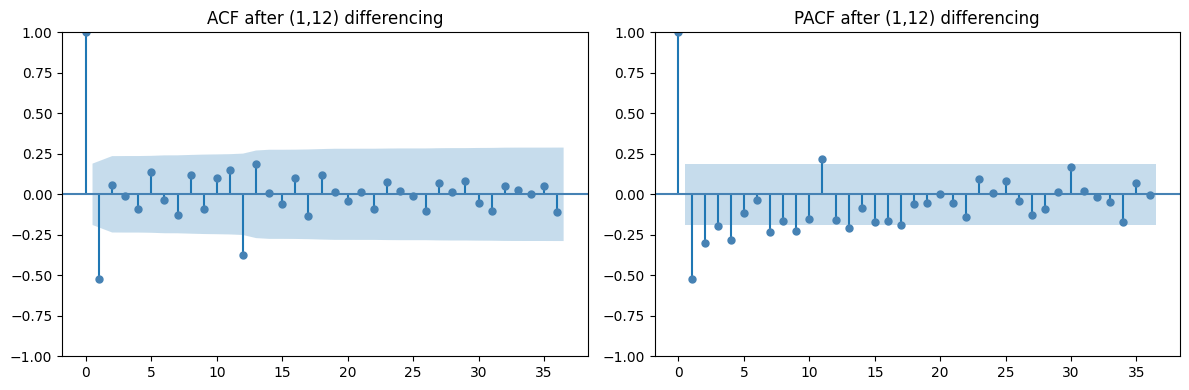

ADF on differenced series: p=0.0000 -> stationary: True


In [2]:
ts_diff = train.diff(1).diff(12).dropna()
fig, axes = plt.subplots(1,2,figsize=(12,4))
plot_acf(ts_diff,  lags=36, ax=axes[0], color="steelblue")
plot_pacf(ts_diff, lags=36, ax=axes[1], color="steelblue", method="ywm")
axes[0].set_title("ACF after (1,12) differencing")
axes[1].set_title("PACF after (1,12) differencing")
plt.tight_layout(); plt.show()
adf_p = adfuller(ts_diff, autolag="AIC")[1]
print(f"ADF on differenced series: p={adf_p:.4f} -> stationary: {adf_p<0.05}")

---
## Fitting SARIMA

In [3]:
# SARIMA(1,1,1)(1,1,1,12) -- trend + seasonal differencing
model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)
print(result.summary())
print(f"\nAIC: {result.aic:.2f}, BIC: {result.bic:.2f}")

                                     SARIMAX Results                                      
Dep. Variable:                            nitrate   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   7.233
Date:                            Thu, 19 Mar 2026   AIC                             -4.465
Time:                                    08:30:54   BIC                              8.198
Sample:                                01-01-2012   HQIC                             0.648
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0008      0.107      0.007      0.994      -0.210       0.211
ma.L1         -0.9990      5.524   

---
## Residual Diagnostics

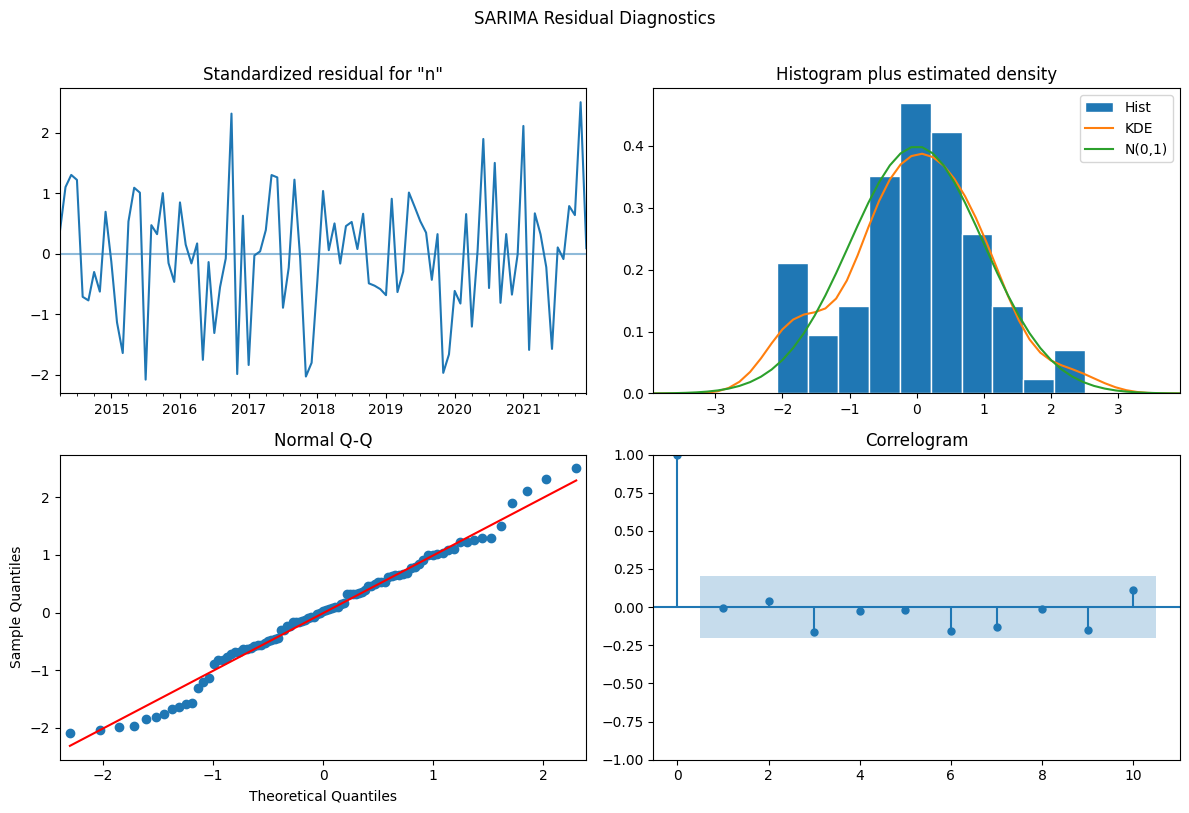

Ljung-Box test (H0: residuals are white noise):
      lb_stat  lb_pvalue
12  24.588194   0.016899
24  32.201842   0.122066

p > 0.05 at all lags -> residuals are white noise -> good fit


In [4]:
fig = result.plot_diagnostics(figsize=(12,8))
plt.suptitle("SARIMA Residual Diagnostics", y=1.01)
plt.tight_layout(); plt.show()
# Ljung-Box test: H0 = residuals are white noise
lb = acorr_ljungbox(result.resid.dropna(), lags=[12,24], return_df=True)
print("Ljung-Box test (H0: residuals are white noise):")
print(lb)
print("\np > 0.05 at all lags -> residuals are white noise -> good fit")

---
## Forecasting and Evaluation

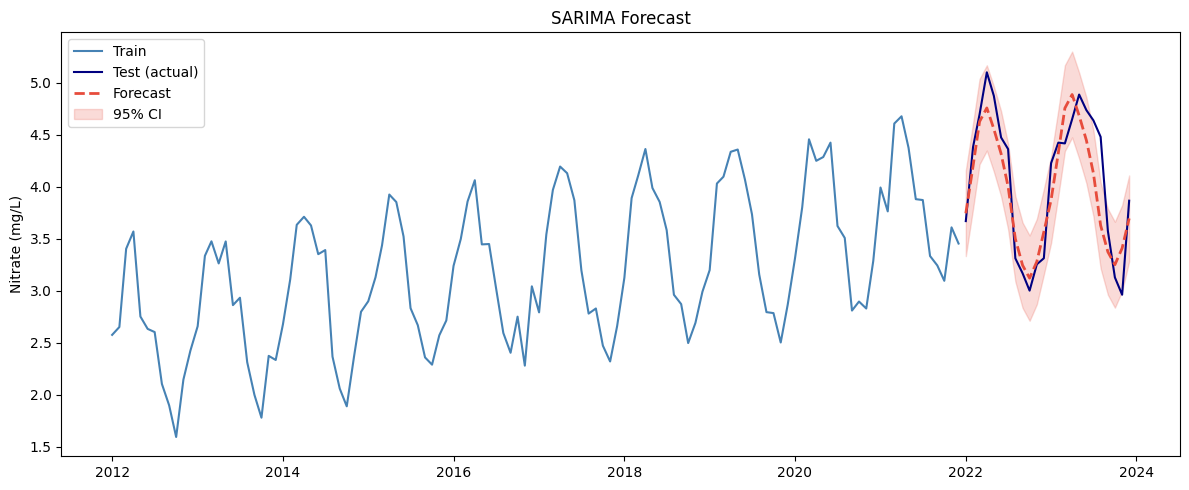

Test RMSE: 0.3053
Test MAE:  0.2496
Test MAPE: 6.08%


In [5]:
# In-sample fit
fitted = result.get_prediction(start=train.index[13], end=train.index[-1])
forecast = result.get_forecast(steps=len(test))
fc_mean = forecast.predicted_mean
fc_ci   = forecast.conf_int(alpha=0.05)
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train, color="steelblue", lw=1.5, label="Train")
ax.plot(test,  color="navy",      lw=1.5, label="Test (actual)")
ax.plot(fc_mean, color="#e74c3c", lw=2, linestyle="--", label="Forecast")
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                alpha=0.2, color="#e74c3c", label="95% CI")
ax.set_ylabel("Nitrate (mg/L)"); ax.set_title("SARIMA Forecast")
ax.legend(); plt.tight_layout(); plt.show()
rmse = np.sqrt(mean_squared_error(test, fc_mean))
mae  = mean_absolute_error(test, fc_mean)
mape = np.mean(np.abs((test - fc_mean) / test)) * 100
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test MAPE: {mape:.2f}%")

---

## Common Pitfalls

**1. Not checking residuals after fitting**  
A well-specified ARIMA should produce white noise residuals. Remaining autocorrelation (Ljung-Box p < 0.05) indicates the model has not captured all temporal structure. Always plot residual diagnostics and run the Ljung-Box test.

**2. Selecting ARIMA orders by AIC/BIC without residual validation**  
AIC/BIC measure in-sample fit penalised for complexity. The model with the lowest AIC may still have autocorrelated residuals. Order selection by information criteria is a starting point, not a final check.

**3. Confusing ARIMA(p,d,q) notation with SARIMA(p,d,q)(P,D,Q,s)**  
SARIMA requires both non-seasonal and seasonal differencing orders. Setting `seasonal_order=(0,0,0,12)` is not the same as using a non-seasonal ARIMA on seasonal data — the seasonal component must be explicitly specified.

**4. Using MAPE when the series contains values near zero**  
MAPE divides by the actual value and becomes unstable or undefined when actuals are near zero (common in ecological count data). Use RMSE or MAE as primary metrics; report MAPE only when all values are safely above zero.

**5. Forecasting far beyond the training horizon without widening uncertainty**  
ARIMA forecast confidence intervals widen with horizon. Multi-step-ahead forecasts more than one seasonal cycle out are often highly uncertain. Always plot the CI and communicate that uncertainty grows with forecast horizon.
---
*python_methods_library - Samantha McGarrigle*